In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression  #Build the model
from sklearn.metrics import mean_absolute_error   #Evaluate the model
from sklearn.utils.validation import check_is_fitted

My ML Workflow
PREPARE
- Import
- Explore
- Split
BUILD MODEL
- Baseline
- Iterate
- Evaluate
COMMUNICATE RESULTS


In [3]:
# Checking the raw data that is provided
df_raw = pd.read_csv(r"C:\Users\Johnt\Downloads\buenos-aires-real-estate-1.csv")
df_raw.info()
print("df_raw.shape:", df_raw.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8606 entries, 0 to 8605
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   8606 non-null   object 
 1   property_type               8606 non-null   object 
 2   place_with_parent_names     8606 non-null   object 
 3   lat-lon                     6936 non-null   object 
 4   price                       7590 non-null   float64
 5   currency                    7590 non-null   object 
 6   price_aprox_local_currency  7590 non-null   float64
 7   price_aprox_usd             7590 non-null   float64
 8   surface_total_in_m2         5946 non-null   float64
 9   surface_covered_in_m2       7268 non-null   float64
 10  price_usd_per_m2            4895 non-null   float64
 11  price_per_m2                6520 non-null   float64
 12  floor                       1259 non-null   float64
 13  rooms                       4752 

In [4]:
df_raw.head()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
1,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|La Matanza...,NaN,250000.0,USD,3790600.0,250000.0,117.0,120.0,2136.752137,2083.333333,NaN,4.0,NaN,http://ramos-mejia.properati.com.ar/s7pd_venta...
2,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Morón|Cast...,"-34.6497002,-58.658073",410000.0,USD,6216584.0,410000.0,410.0,220.0,1000.000000,1863.636364,NaN,NaN,NaN,http://castelar-moron.properati.com.ar/11vgn_v...
3,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Tres de Fe...,"-34.5957086,-58.5669503",180000.0,USD,2729232.0,180000.0,200.0,135.0,900.000000,1333.333333,NaN,5.0,NaN,http://tres-de-febrero.properati.com.ar/7f7u_v...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...


IMPORT DATA

In [5]:
def wrangle(filepath):
    # Read CSV file into dataframe
    df = pd.read_csv(filepath)

    # Subset to properties in `"Capital Federal"`
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")

    # Subset to `"apartments"`
    mask_apt = df["property_type"] == "apartment"

    # Subset to properties where `"price_aprox_usd"` < 400_000
    mask_price = df["price_aprox_usd"] < 400_000

    df = df[mask_ba & mask_apt & mask_price]

    # Removing outliers by `"Surface_area_covered_m2"`
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]


    return df

In [6]:
df = wrangle(r"C:\Users\Johnt\Downloads\buenos-aires-real-estate-1.csv")
print("df shape:", df.shape)
df.head()

df shape: (1343, 16)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
29,sell,apartment,|Argentina|Capital Federal|Caballito|,"-34.615847,-58.459957",118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...
40,sell,apartment,|Argentina|Capital Federal|Constitución|,"-34.6252219,-58.3823825",57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364.0,http://constitucion.properati.com.ar/k2f0_vent...
41,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6106102,-58.4125107",90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450.0,http://once.properati.com.ar/suwa_venta_depart...


In [7]:
assert(
    len(df) <= 8606
), f"`df` should have no more than 8606 observations, not {len(df)}"

EXPLORE DATA

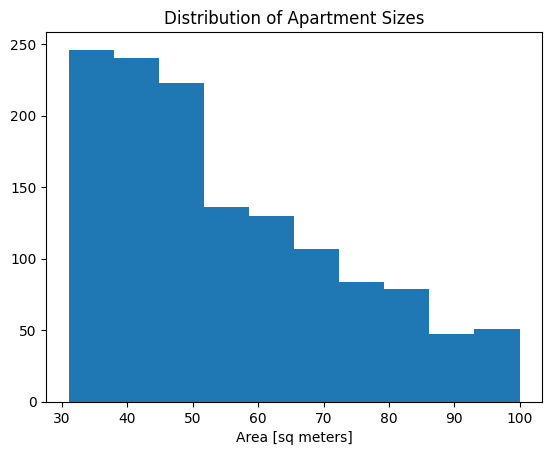

In [8]:
plt.hist(df["surface_covered_in_m2"])
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Apartment Sizes");

The data is right-skewed (positively skewed). This means that the vast majority of apartments are concentrated on the smaller end of the spectrum (30 to 60 $m^2$), with the frequency dropping sharply as size increases. Most of the apartments in this specific dataset are smaller than 73 square meters. You can see the tallest bars (highest frequency) are between 30 and 50 $m^2$.

In [9]:
df.describe()["surface_covered_in_m2"]

count    1343.000000
mean       55.076694
std        18.160427
min        31.000000
25%        40.000000
50%        50.000000
75%        68.500000
max       100.000000
Name: surface_covered_in_m2, dtype: float64

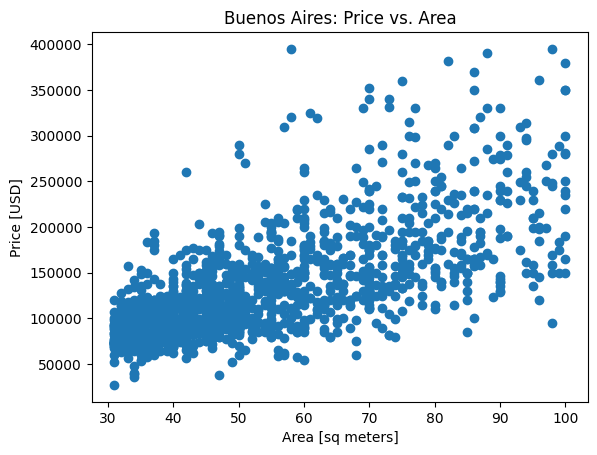

In [10]:
plt.scatter(x=df["surface_covered_in_m2"], y=df["price_aprox_usd"])
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs. Area");

SPLIT

In [11]:
features = ["surface_covered_in_m2"]
X_train = df[features]
X_train.shape

(1343, 1)

In [12]:
assert X_train.shape == (
    1343,
    1,
), f"The shape of `X_train` should be (1343, 1), not {X_train.shape}."

In [13]:
target = "price_aprox_usd"
y_train = df[target]
y_train.shape

(1343,)

In [14]:
assert y_train.shape == (1343,)

BUILD MODEL

In [15]:
# Set up a Baseline for the Model
y_mean = y_train.mean()
y_mean

np.float64(135527.83871928515)

In [16]:
y_pred_baseline = [y_mean] * len(y_train)
y_pred_baseline[:5]

[np.float64(135527.83871928515),
 np.float64(135527.83871928515),
 np.float64(135527.83871928515),
 np.float64(135527.83871928515),
 np.float64(135527.83871928515)]

In [17]:
(X_train.values)

array([[70.],
       [42.],
       [54.],
       ...,
       [43.],
       [70.],
       [52.]], shape=(1343, 1))

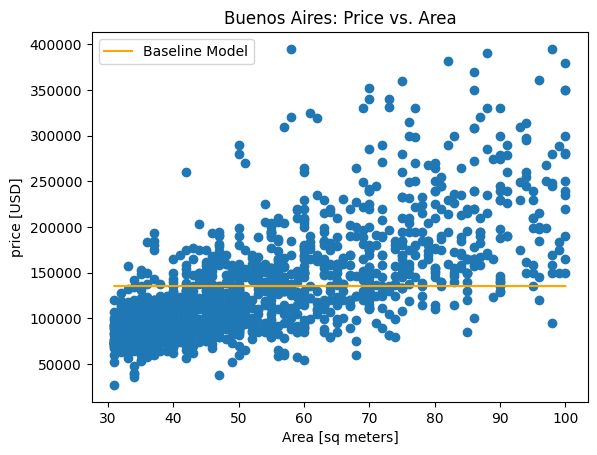

In [18]:
# Add a line to the plot
plt.plot(X_train["surface_covered_in_m2"], y_pred_baseline, color="orange", label="Baseline Model")
plt.scatter(X_train, y_train)
plt.xlabel("Area [sq meters]")
plt.ylabel("price [USD]")
plt.title("Buenos Aires: Price vs. Area")
plt.legend();

In [19]:
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean apt price:", round(y_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean apt price: 135527.84
Baseline MAE: 45199.46


Iterate

In [20]:
# Instantiate the model
model = LinearRegression()

In [21]:
# Check the model
assert isinstance(model, LinearRegression)

In [22]:
# Fit Model on Dataset
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
# Check the work 
check_is_fitted(model)

EVALUATE

In [24]:
y_pred_training = model.predict(X_train)
y_pred_training[:5]

array([169151.87330223, 106064.44707446, 133101.91545779, 106064.44707446,
       124089.42599668])

In [25]:
# check the work 
assert(
    len(y_pred_training) == 1343
), f"There should be 1343 predictions in `y_pred_training`, not {len(y_pred_training)}."

In [26]:
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE:", round(mae_training, 2))

Training MAE: 31248.26


In [27]:
X_test = pd.read_csv(r"C:\Users\Johnt\Downloads\buenos-aires-test-features.csv.csv")[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

0    117330.058901
1    135355.037823
2     88039.468152
3     88039.468152
4    106064.447074
dtype: float64

COMMUNICATE RESULTS


In [28]:
# Extract the Intercept
intercept = round(model.intercept_, 2)
print("Model Intercept:", intercept)

assert any([isinstance(intercept, int), isinstance(intercept, float)])

Model Intercept: 11433.31


In [30]:
# Extract Coefficient
coefficient = round(model.coef_[0], 2)
print('Model coefficient for "surface_covered_in_m2":', coefficient)

assert any([isinstance(coefficient, int), isinstance(coefficient, float)])


Model coefficient for "surface_covered_in_m2": 2253.12


In [31]:
print(f"apartment_price = {intercept} + {coefficient} * surface_covered")

apartment_price = 11433.31 + 2253.12 * surface_covered


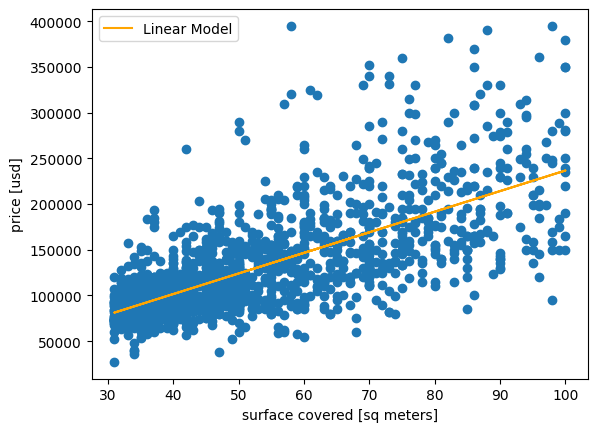

In [32]:
# Visualization of Prediction

plt.plot(X_train.values, model.predict(X_train), color="orange", label="Linear Model")
plt.scatter(X_train, y_train)
plt.xlabel("surface covered [sq meters]")
plt.ylabel("price [usd]")
plt.legend();